# ISYE 671: Linear Optimization and Network Flows
# Lab: Solving Integer Programming Models

**Instructor:** Dr. Ziteng Wang | **Date:** February 16, 2026

---

**Objectives:**

By the end of this lab, you will be able to:

1. Solve integer and mixed-integer programs using AMPL + Python in Google Colab
2. Compare LP relaxation solutions with IP solutions and interpret the integrality gap
3. Understand branch-and-bound through solver output and a manual implementation
4. Observe the effect of cutting planes and problem scaling on solver performance
5. Read and interpret Gurobi MIP solver logs

**Prerequisites:** AMPL syntax for LP models (from Lab 1); integer optimization modeling (from last week's lecture)

---


## Part 1: Environment Setup


In [ ]:
# Install AMPL Python API
!pip install -q amplpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.9 MB/s eta 0:00:00


In [ ]:
from amplpy import AMPL, ampl_notebook

# Initialize AMPL with Gurobi solver for Colab environment
# Get your own free license at: https://ampl.com/ce or https://ampl.com/courses
ampl = ampl_notebook(
    modules=["gurobi"],  # Gurobi: powerful commercial MIP solver (free academic license)
    license_uuid="YOUR-AMPL-LICENSE-UUID"
)

print("AMPL environment ready with Gurobi solver!")


Licensed to Bundle #7384.7942 expiring 20260531: ISYE 671 linear optimization and network flows, Prof. Ziteng Wang, Northern Illinois University.
AMPL environment ready with Gurobi solver!


In [ ]:
# Utility imports
import time
import matplotlib.pyplot as plt
import numpy as np


---

## Part 2: LP Relaxation and the Integrality Gap

### Why LP relaxation matters

Every IP solver begins by solving the LP relaxation — the same model but with integrality constraints dropped. The LP relaxation provides a **bound** on the IP optimal value:

- **Minimization:** $z^*_{LP} \leq z^*_{IP}$ (lower bound)
- **Maximization:** $z^*_{LP} \geq z^*_{IP}$ (upper bound)

The **integrality gap** = $\frac{|z^*_{IP} - z^*_{LP}|}{|z^*_{IP}|} \times 100\%$ measures how "tight" the LP relaxation is. A small gap means the LP relaxation closely approximates the IP, and the solver has less work to do.

Let's compute this for several of our models from last week.


### Example 1: Swedish Steel — Fixed Charges

Recall the fixed-charge blending model: select ingredients to minimize total cost (variable + setup), subject to chemical composition constraints. Binary variables $y_j$ indicate whether ingredient $j$'s setup cost is incurred, linked to continuous quantities $x_j$ via switching constraints $x_j \leq u_j y_j$.


In [ ]:
%%writefile swedish_steel.mod
# ============================================================
# Swedish Steel Fixed-Charge Model (Rardin, Model 11.4)
# ============================================================

set INGREDIENTS;
set ELEMENTS;
set SETUP_INGREDIENTS within INGREDIENTS;

param cost {INGREDIENTS};
param setup_cost {SETUP_INGREDIENTS};
param upper_bound {INGREDIENTS};
param composition {INGREDIENTS, ELEMENTS};
param elem_min {ELEMENTS};
param elem_max {ELEMENTS};
param total_weight;

# Decision variables
var x {j in INGREDIENTS} >= 0;
var y {j in SETUP_INGREDIENTS} >= 0, <= 1;  # Will be binary or relaxed

minimize total_cost:
    sum {j in INGREDIENTS} cost[j] * x[j]
    + sum {j in SETUP_INGREDIENTS} setup_cost[j] * y[j];

subject to weight:
    sum {j in INGREDIENTS} x[j] = total_weight;

subject to elem_lower {e in ELEMENTS}:
    sum {j in INGREDIENTS} composition[j,e] * x[j] >= elem_min[e];

subject to elem_upper {e in ELEMENTS}:
    sum {j in INGREDIENTS} composition[j,e] * x[j] <= elem_max[e];

subject to switching {j in SETUP_INGREDIENTS}:
    x[j] <= upper_bound[j] * y[j];


Writing swedish_steel.mod


In [ ]:
%%writefile swedish_steel.dat
set INGREDIENTS := Scrap1 Scrap2 Scrap3 Scrap4 NiPure CrPure MoPure;
set ELEMENTS := Carbon Nickel Chromium Molybdenum;
set SETUP_INGREDIENTS := Scrap1 Scrap2 Scrap3 Scrap4;

param total_weight := 1000;

param cost :=
    Scrap1  16   Scrap2  10   Scrap3  8    Scrap4  9
    NiPure  48   CrPure  60   MoPure  53;

param setup_cost :=
    Scrap1  350  Scrap2  350  Scrap3  350  Scrap4  350;

param upper_bound :=
    Scrap1  75   Scrap2  250  Scrap3  1000  Scrap4  1000;

param composition (tr):
                Scrap1   Scrap2   Scrap3   Scrap4   NiPure  CrPure  MoPure :=
    Carbon      0.0080   0.0070   0.0085   0.0040   0       0       0
    Nickel      0.1800   0.0320   0        0        1.0     0       0
    Chromium    0.1200   0.0110   0        0        0       1.0     0
    Molybdenum  0        0.0010   0        0        0       0       1.0;

param elem_min :=
    Carbon 6.5   Nickel 30   Chromium 10   Molybdenum 11;

param elem_max :=
    Carbon 7.5   Nickel 35   Chromium 12   Molybdenum 13;


Writing swedish_steel.dat


In [ ]:
# ============================================================
# Solve LP relaxation (y is continuous [0,1])
# ============================================================
steel_lp = AMPL()
steel_lp.read("swedish_steel.mod")
steel_lp.read_data("swedish_steel.dat")
steel_lp.option["solver"] = "gurobi"
steel_lp.solve()

z_lp = steel_lp.get_value("total_cost")
print("=" * 60)
print("SWEDISH STEEL — LP RELAXATION")
print("=" * 60)
print(f"Objective: {z_lp:.1f} kroner")
print()
print("Setup variables (continuous — can be fractional):")
for j in steel_lp.set["SETUP_INGREDIENTS"].members():
    yval = steel_lp.var["y"][j].value()
    xval = steel_lp.var["x"][j].value()
    print(f"  {j:>8}: y = {yval:.4f}, x = {xval:.2f} kg")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 10630.83056
2 simplex iterations
SWEDISH STEEL — LP RELAXATION
Objective: 10630.8 kroner

Setup variables (continuous — can be fractional):
    Scrap1: y = 1.0000, x = 75.00 kg
    Scrap2: y = 0.0000, x = 0.00 kg
    Scrap3: y = 0.7364, x = 736.44 kg
    Scrap4: y = 0.1601, x = 160.06 kg


In [ ]:
# ============================================================
# Solve IP (y is binary)
# ============================================================
steel_ip = AMPL()
steel_ip.read("swedish_steel.mod")
steel_ip.read_data("swedish_steel.dat")

# Make y binary
steel_ip.eval("redeclare var y {j in SETUP_INGREDIENTS} binary;")

steel_ip.option["solver"] = "gurobi"
steel_ip.solve()

z_ip = steel_ip.get_value("total_cost")
print("=" * 60)
print("SWEDISH STEEL — INTEGER PROGRAM")
print("=" * 60)
print(f"Objective: {z_ip:.1f} kroner")
print()
print("Setup decisions:")
for j in steel_ip.set["SETUP_INGREDIENTS"].members():
    yval = steel_ip.var["y"][j].value()
    xval = steel_ip.var["x"][j].value()
    status = "SETUP" if yval > 0.5 else "skip"
    print(f"  {j:>8}: y = {yval:.0f} ({status}), x = {xval:.2f} kg")

print()
gap = abs(z_ip - z_lp) / abs(z_ip) * 100
print(f"LP relaxation:  {z_lp:.1f}")
print(f"IP optimal:     {z_ip:.1f}")
print(f"Integrality gap: {gap:.2f}%")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 11017.05556
3 simplex iterations
1 branching node
SWEDISH STEEL — INTEGER PROGRAM
Objective: 11017.1 kroner

Setup decisions:
    Scrap1: y = 1 (SETUP), x = 75.00 kg
    Scrap2: y = 0 (skip), x = 0.00 kg
    Scrap3: y = 1 (SETUP), x = 736.44 kg
    Scrap4: y = 1 (SETUP), x = 160.06 kg

LP relaxation:  10630.8
IP optimal:     11017.1
Integrality gap: 3.51%


**Discussion:** Notice how the LP relaxation can "partially" set up ingredients — paying a fraction of the setup cost while using a fraction of the ingredient. The IP forces a commit-or-skip decision, which is more expensive. The integrality gap tells us how much the "lumpiness" costs.


### Example 2: NASA Capital Budgeting

The NASA model selects missions to maximize scientific value subject to stage budgets, mutual exclusivity, and dependency constraints. All variables are binary, so the LP relaxation allows fractional mission selection.


In [ ]:
%%writefile nasa.mod
# ============================================================
# NASA Capital Budgeting Model (Rardin, Model 11.7)
# ============================================================

set MISSIONS;
set STAGES;
set CONFLICTS within {MISSIONS, MISSIONS};
set DEPENDENCIES within {MISSIONS, MISSIONS};

param budget_req {MISSIONS, STAGES} default 0;
param budget_avail {STAGES};
param value {MISSIONS};

var x {MISSIONS} >= 0, <= 1;  # Will be binary or relaxed

maximize total_value:
    sum {j in MISSIONS} value[j] * x[j];

subject to budget {t in STAGES}:
    sum {j in MISSIONS} budget_req[j,t] * x[j] <= budget_avail[t];

subject to exclusive {(j1, j2) in CONFLICTS}:
    x[j1] + x[j2] <= 1;

subject to dependency {(j, i) in DEPENDENCIES}:
    x[j] <= x[i];


Writing nasa.mod


In [ ]:
%%writefile nasa.dat
set MISSIONS := M1 M2 M3 M4 M5 M6 M7 M8 M9 M10 M11 M12 M13 M14;
set STAGES := S1 S2 S3 S4 S5;

set CONFLICTS :=
    (M4, M5)
    (M8, M11)
    (M9, M14);

set DEPENDENCIES :=
    (M11, M2)
    (M4,  M3)
    (M5,  M3)
    (M6,  M3)
    (M7,  M3);

param value :=
    M1 200   M2 3     M3 20    M4 50    M5 70
    M6 20    M7 5     M8 10    M9 200   M10 150
    M11 18   M12 8    M13 300  M14 185;

param budget_avail :=
    S1 10  S2 12  S3 14  S4 14  S5 14;

param budget_req:
         S1   S2   S3   S4   S5 :=
    M1    6    0    0    0    0
    M2    2    3    0    0    0
    M3    3    5    0    0    0
    M4    0    0    0    0   10
    M5    0    5    8    0    0
    M6    0    0    1    8    4
    M7    1    8    0    0    0
    M8    0    0    0    5    0
    M9    4    5    0    0    0
    M10   0    8    4    0    0
    M11   0    0    2    7    0
    M12   5    7    0    0    0
    M13   0    1    4    1    1
    M14   0    4    5    3    3;


Writing nasa.dat


In [ ]:
# ============================================================
# NASA: LP relaxation vs IP
# ============================================================

# LP relaxation
nasa_lp = AMPL()
nasa_lp.read("nasa.mod")
nasa_lp.read_data("nasa.dat")
nasa_lp.option["solver"] = "gurobi"
nasa_lp.solve()

z_lp_nasa = nasa_lp.get_value("total_value")
print("=" * 60)
print("NASA — LP RELAXATION")
print("=" * 60)
print(f"Total value (LP): {z_lp_nasa:.1f}")
print()
print("Mission selections (fractional allowed):")
for m in nasa_lp.set["MISSIONS"].members():
    xval = nasa_lp.var["x"][m].value()
    val = nasa_lp.param["value"][m]
    if xval > 0.001:
        marker = "***" if 0.001 < xval < 0.999 else ""
        print(f"  {m}: x = {xval:.4f}  (value = {val})  {marker}")
print("  *** = fractional selection")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 826.25
9 simplex iterations
NASA — LP RELAXATION
Total value (LP): 826.2

Mission selections (fractional allowed):
  M1: x = 1.0000  (value = 200)  
  M8: x = 1.0000  (value = 10)  
  M10: x = 0.8750  (value = 150)  ***
  M13: x = 1.0000  (value = 300)  
  M14: x = 1.0000  (value = 185)  
  *** = fractional selection


In [ ]:
# IP (binary)
nasa_ip = AMPL()
nasa_ip.read("nasa.mod")
nasa_ip.read_data("nasa.dat")
nasa_ip.eval("redeclare var x {MISSIONS} binary;")
nasa_ip.option["solver"] = "gurobi"
nasa_ip.solve()

z_ip_nasa = nasa_ip.get_value("total_value")
print("=" * 60)
print("NASA — INTEGER PROGRAM")
print("=" * 60)
print(f"Total value (IP): {z_ip_nasa:.1f}")
print()
print("Selected missions:")
for m in nasa_ip.set["MISSIONS"].members():
    xval = nasa_ip.var["x"][m].value()
    val = nasa_ip.param["value"][m]
    if xval > 0.5:
        print(f"  {m}: SELECTED  (value = {val})")

print()
gap = abs(z_ip_nasa - z_lp_nasa) / abs(z_ip_nasa) * 100
print(f"LP relaxation:  {z_lp_nasa:.1f}")
print(f"IP optimal:     {z_ip_nasa:.1f}")
print(f"Integrality gap: {gap:.2f}%")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 765
7 simplex iterations
1 branching node
NASA — INTEGER PROGRAM
Total value (IP): 765.0

Selected missions:
  M1: SELECTED  (value = 200)
  M3: SELECTED  (value = 20)
  M4: SELECTED  (value = 50)
  M8: SELECTED  (value = 10)
  M13: SELECTED  (value = 300)
  M14: SELECTED  (value = 185)

LP relaxation:  826.2
IP optimal:     765.0
Integrality gap: 8.01%


**Discussion:** The LP relaxation can fractionally select missions — "half-funding" a mission to use part of the budget. The IP must fully commit. Observe which missions have fractional values in the LP relaxation — these are the "hard" decisions the solver must resolve.


### Example 3: EMS Location (Set Covering)

The EMS model places ambulance stations to cover all demand zones. Each zone must be within the service radius of at least one station.


In [ ]:
%%writefile ems.mod
# ============================================================
# EMS Set Covering Model (Rardin, Model 11.9)
# ============================================================

set ZONES;
set SITES;
set COVERS {ZONES} within SITES;

param fixed_cost {SITES};

var x {SITES} >= 0, <= 1;  # Will be binary or relaxed

minimize total_cost:
    sum {s in SITES} fixed_cost[s] * x[s];

subject to cover {z in ZONES}:
    sum {s in COVERS[z]} x[s] >= 1;


Writing ems.mod


In [ ]:
%%writefile ems.dat
set ZONES := Z1 Z2 Z3 Z4 Z5 Z6;
set SITES := S1 S2 S3 S4 S5 S6;

set COVERS[Z1] := S1 S2;
set COVERS[Z2] := S1 S2 S6;
set COVERS[Z3] := S3 S4;
set COVERS[Z4] := S3 S4 S5;
set COVERS[Z5] := S4 S5 S6;
set COVERS[Z6] := S5 S6;

param fixed_cost :=
    S1 100  S2 120  S3 110  S4 130  S5 90  S6 115;


Writing ems.dat


In [ ]:
# EMS: LP relaxation vs IP
ems_lp = AMPL()
ems_lp.read("ems.mod")
ems_lp.read_data("ems.dat")
ems_lp.option["solver"] = "gurobi"
ems_lp.solve()

z_lp_ems = ems_lp.get_value("total_cost")

ems_ip = AMPL()
ems_ip.read("ems.mod")
ems_ip.read_data("ems.dat")
ems_ip.eval("redeclare var x {SITES} binary;")
ems_ip.option["solver"] = "gurobi"
ems_ip.solve()

z_ip_ems = ems_ip.get_value("total_cost")

print("=" * 60)
print("EMS SET COVERING — LP vs IP")
print("=" * 60)
print(f"LP relaxation: {z_lp_ems:.1f}")
print(f"IP optimal:    {z_ip_ems:.1f}")
gap = abs(z_ip_ems - z_lp_ems) / abs(z_ip_ems) * 100
print(f"Integrality gap: {gap:.2f}%")
print()

print("LP solution:")
for s in ems_lp.set["SITES"].members():
    xval = ems_lp.var["x"][s].value()
    if xval > 0.001:
        print(f"  {s}: x = {xval:.4f}")

print()
print("IP solution:")
for s in ems_ip.set["SITES"].members():
    xval = ems_ip.var["x"][s].value()
    if xval > 0.5:
        print(f"  {s}: OPEN")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 300
3 simplex iterations
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 300
0 simplex iterations
EMS SET COVERING — LP vs IP
LP relaxation: 300.0
IP optimal:    300.0
Integrality gap: 0.00%

LP solution:
  S1: x = 1.0000
  S3: x = 1.0000
  S5: x = 1.0000

IP solution:
  S1: OPEN
  S3: OPEN
  S5: OPEN


### Integrality Gap Summary

Let's collect the gaps for all our models.


In [ ]:
# ============================================================
# Summary comparison across models
# ============================================================

print("=" * 65)
print(f"{'Model':<25} {'LP Relax':>10} {'IP Opt':>10} {'Gap':>10}")
print("=" * 65)

models = [
    ("Swedish Steel (min)", z_lp, z_ip),
    ("NASA Budgeting (max)", z_lp_nasa, z_ip_nasa),
    ("EMS Covering (min)", z_lp_ems, z_ip_ems),
]

for name, lp_val, ip_val in models:
    gap = abs(ip_val - lp_val) / abs(ip_val) * 100
    print(f"{name:<25} {lp_val:>10.1f} {ip_val:>10.1f} {gap:>9.2f}%")

print()
print("Key insight: Tighter LP relaxations (smaller gaps) mean")
print("the solver has less work to do in the branch-and-bound tree.")


Model                       LP Relax     IP Opt        Gap
Swedish Steel (min)          10630.8    11017.1      3.51%
NASA Budgeting (max)           826.2      765.0      8.01%
EMS Covering (min)             300.0      300.0      0.00%

Key insight: Tighter LP relaxations (smaller gaps) mean
the solver has less work to do in the branch-and-bound tree.


---

## Part 3: Branch and Bound — Step by Step

### Manual B&B on a Small Example

Let's trace branch and bound on a small problem to see how it works. We'll solve each LP relaxation subproblem with AMPL and track the tree ourselves.


In [ ]:
%%writefile bb_example.mod
# Small IP for B&B demonstration
var x1 >= 0;
var x2 >= 0;

param x1_lo default 0;
param x1_hi default 100;
param x2_lo default 0;
param x2_hi default 100;

maximize profit: 4 * x1 + 5 * x2;

subject to c1: x1 + x2 <= 5;
subject to c2: 6 * x1 + 10 * x2 <= 45;
subject to x1_lb: x1 >= x1_lo;
subject to x1_ub: x1 <= x1_hi;
subject to x2_lb: x2 >= x2_lo;
subject to x2_ub: x2 <= x2_hi;


Writing bb_example.mod


In [ ]:
def solve_bb_node(x1_bounds, x2_bounds, node_name):
    """Solve one B&B subproblem and report results."""
    m = AMPL()
    m.read("bb_example.mod")
    m.param["x1_lo"] = x1_bounds[0]
    m.param["x1_hi"] = x1_bounds[1]
    m.param["x2_lo"] = x2_bounds[0]
    m.param["x2_hi"] = x2_bounds[1]
    m.option["solver"] = "gurobi"
    m.solve()

    status = m.get_value("solve_result")
    if "infeasible" in status or "unbounded" in status:
        print(f"  {node_name}: {status.upper().split(' ')[0]} — pruned")
        return None, None, None, False, status

    x1_val = m.var["x1"].value()
    x2_val = m.var["x2"].value()
    obj = m.get_value("profit")
    # Check for integrality with a small tolerance
    is_int = (abs(x1_val - round(x1_val)) < 1e-6 and
              abs(x2_val - round(x2_val)) < 1e-6)

    print(f"  {node_name}: x1={x1_val:.3f}, x2={x2_val:.3f}, "
          f"z={obj:.2f}  {'[INTEGER]' if is_int else '[fractional]'}")
    return x1_val, x2_val, obj, is_int, status


print("=" * 60)
print("BRANCH AND BOUND — STEP BY STEP")
print("=" * 60)

# Initialize incumbent (for maximization problems, start very low)
incumbent = -float('inf')
incumbent_x1 = None
incumbent_x2 = None

# Helper to update incumbent if a better integer solution is found
def update_incumbent_if_better(obj_val, x1_val, x2_val, node_name):
    global incumbent, incumbent_x1, incumbent_x2  # Declare global to modify
    if obj_val is not None and obj_val > incumbent:
        incumbent = obj_val
        incumbent_x1 = x1_val
        incumbent_x2 = x2_val
        print(f"  ** New incumbent (from {node_name}): z = {incumbent:.0f}, x1={incumbent_x1:.0f}, x2={incumbent_x2:.0f}")
    elif obj_val is not None:
        print(f"  ** Integer solution from {node_name} (z={obj_val:.0f}) not better than current incumbent ({incumbent:.0f}) — pruned")

# Node 0: Root LP relaxation
print("\nNode 0 (Root — no branching constraints):")
x1_0, x2_0, z0, int0, status0 = solve_bb_node([0, 100], [0, 100], "Root")

# If root node is infeasible or we cannot get an objective, exit
if z0 is None:
    print("Root node did not yield a valid LP solution. Exiting B&B.")
else:
    # Branch on x2 (fractional part of x2_0)
    print(f"\n  Branch on x2 (LP value = {x2_0:.3f}):")
    print(f"  Left:  x2 <= {int(x2_0)}")
    print(f"  Right: x2 >= {int(x2_0) + 1}")

    # Node 1: x2 <= floor(x2_0)
    print(f"\nNode 1 (x2 <= {int(x2_0)}):")
    x1_1, x2_1, z1, int1, status1 = solve_bb_node([0, 100], [0, int(x2_0)], "Node 1")
    if int1: # If integer, check if it's a new incumbent
        update_incumbent_if_better(z1, x1_1, x2_1, "Node 1")

    # Node 2: x2 >= ceil(x2_0)
    print(f"\nNode 2 (x2 >= {int(x2_0) + 1}):")
    x1_2, x2_2, z2, int2, status2 = solve_bb_node([0, 100], [int(x2_0) + 1, 100], "Node 2")
    if int2: # If integer, check if it's a new incumbent
        update_incumbent_if_better(z2, x1_2, x2_2, "Node 2")

    # Branching logic for nodes that are fractional and whose LP bound is better than current incumbent

    # Only branch Node 2 further if it was fractional and its bound is better than the incumbent
    if not int2 and z2 is not None and z2 > incumbent: # Prune if z2 <= incumbent
        print(f"\n  Branch Node 2 on x1 (LP value = {x1_2:.3f}):")

        # Node 5: x1 <= floor(x1_2), x2 >= ceil(x2_0)
        print(f"\nNode 5 (x1 <= {int(x1_2)}, x2 >= {int(x2_0)+1}):")
        x1_5, x2_5, z5, int5, status5 = solve_bb_node([0, int(x1_2)], [int(x2_0)+1, 100], "Node 5")
        if int5: # If integer, check if it's a new incumbent
            update_incumbent_if_better(z5, x1_5, x2_5, "Node 5")
        elif z5 is not None and z5 <= incumbent: # Prune fractional node if its bound is not better
            print(f"  ** Node 5 bound ({z5:.2f}) <= incumbent ({incumbent:.0f}) — pruned")

        # Node 6: x1 >= ceil(x1_2), x2 >= ceil(x2_0)
        print(f"\nNode 6 (x1 >= {int(x1_2)+1}, x2 >= {int(x2_0)+1}):")
        x1_6, x2_6, z6, int6, status6 = solve_bb_node([int(x1_2)+1, 100], [int(x2_0)+1, 100], "Node 6")
        if int6: # If integer, check if it's a new incumbent
            update_incumbent_if_better(z6, x1_6, x2_6, "Node 6")
        elif z6 is not None and z6 <= incumbent: # Prune fractional node if its bound is not better
            print(f"  ** Node 6 bound ({z6:.2f}) <= incumbent ({incumbent:.0f}) — pruned")
    elif z2 is not None and z2 <= incumbent:
        print(f"\nNode 2 bound ({z2:.2f}) <= incumbent ({incumbent:.0f}) — pruned!")

print(f"\n{'='*60}")
if incumbent_x1 is not None and incumbent_x2 is not None:
    print(f"OPTIMAL INTEGER SOLUTION: z* = {incumbent:.0f} (x1={incumbent_x1:.0f}, x2={incumbent_x2:.0f})")
else:
    print("No integer solution found within explored nodes.")
print(f"{'='*60}")


BRANCH AND BOUND — STEP BY STEP

Node 0 (Root — no branching constraints):
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 23.75
1 simplex iteration
  Root: x1=1.250, x2=3.750, z=23.75  [fractional]

  Branch on x2 (LP value = 3.750):
  Left:  x2 <= 3
  Right: x2 >= 4

Node 1 (x2 <= 3):
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 23
1 simplex iteration
  Node 1: x1=2.000, x2=3.000, z=23.00  [INTEGER]
  ** New incumbent (from Node 1): z = 23, x1=2, x2=3

Node 2 (x2 >= 4):
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 23.33333333
2 simplex iterations
  Node 2: x1=0.833, x2=4.000, z=23.33  [fractional]

  Branch Node 2 on x1 (LP value = 0.833):

Node 5 (x1 <= 0, x2 >= 4):
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 22.5
0 simplex iterations


	presolve: constraint c2 cannot hold:
		body <= 45 cannot be >= 46; difference = -1
	presolve, constraint c2:
		all variables eliminated, but upper bound = -1 < 0


  Node 5: x1=0.000, x2=4.500, z=22.50  [fractional]
  ** Node 5 bound (22.50) <= incumbent (23) — pruned

Node 6 (x1 >= 1, x2 >= 4):
Infeasible constraints determined by presolve.
  Node 6: INFEASIBLE — pruned

OPTIMAL INTEGER SOLUTION: z* = 23 (x1=2, x2=3)


**Key observations:**
- The root LP relaxation gives an upper bound.
- Each branch creates tighter subproblems.
- Pruning eliminates subproblems that cannot beat the incumbent.
- The solver does this automatically — but understanding the process helps you formulate better models.


---

## Part 4: Interpreting Gurobi MIP Solver Output

When Gurobi solves a MIP, it produces a detailed log showing the branch-and-cut progress. Let's solve our larger models with verbose output and learn to read the log.

### Key elements of the Gurobi log:

- **Presolve**: Model simplifications (removed rows/cols, tightened bounds)
- **Root relaxation**: The LP bound at the root node
- **Node table**: Each row shows nodes explored, current bounds, and gap
- **H / \***: "H" = heuristic found a feasible solution; "\*" = new best integer solution found
- **Gap**: When it reaches 0%, the solution is provably optimal


In [ ]:
%%writefile wastewater.mod
# ============================================================
# Wastewater Network Design Model (Rardin, Model 11.21)
# ============================================================

set NODES;
set ARCS within {NODES, NODES};

param supply {NODES};
param fixed_cost {ARCS};
param var_cost {ARCS};
param capacity {ARCS};

var flow {(i,j) in ARCS} >= 0;
var build {ARCS} binary;

minimize total_cost:
    sum {(i,j) in ARCS} (var_cost[i,j] * flow[i,j] + fixed_cost[i,j] * build[i,j]);

subject to balance {k in NODES}:
    sum {(i,k) in ARCS} flow[i,k] - sum {(k,j) in ARCS} flow[k,j] = supply[k];

subject to switching {(i,j) in ARCS}:
    flow[i,j] <= capacity[i,j] * build[i,j];


Writing wastewater.mod


In [ ]:
%%writefile wastewater.dat
set NODES := N1 N2 N3 N4 N5 N6 N7 N8 N9;
set ARCS :=
    (N1,N2) (N1,N3)
    (N2,N3) (N2,N4)
    (N3,N4) (N3,N9)
    (N4,N3) (N4,N8)
    (N5,N6) (N5,N7)
    (N6,N7) (N6,N8)
    (N7,N4) (N7,N9)
    (N8,N9);

param supply :=
    N1 -27  N2 -3   N3 -14  N4 -36
    N5 -21  N6 -8   N7 -13  N8 0    N9 122;

param:          fixed_cost  var_cost  capacity :=
    N1 N2       240         21        27
    N1 N3       350         30        27
    N2 N3       200         22        30
    N2 N4       750         58        30
    N3 N4       610         43        44
    N3 N9       3800        1         122
    N4 N3       1840        49        108
    N4 N8       780         63        122
    N5 N6       620         44        21
    N5 N7       800         51        21
    N6 N7       500         56        29
    N6 N8       630         94        29
    N7 N4       1120        82        42
    N7 N9       3800        1         42
    N8 N9       2500        2         122;


Writing wastewater.dat


In [ ]:
# Solve with Gurobi verbose output
waste_model = AMPL()
waste_model.read("wastewater.mod")
waste_model.read_data("wastewater.dat")
waste_model.option["solver"] = "gurobi"
# Combined Gurobi options: verbose log, no cuts, disable heuristics (set to 0.0), display all nodes
waste_model.option["gurobi_options"] = "outlev=1 presolve=0 cuts=0"
waste_model.solve()

print()
print("=" * 60)
print("WASTEWATER NETWORK DESIGN — RESULTS")
print("=" * 60)
print(f"Total cost: {waste_model.get_value('total_cost'):.0f}")
print(f"Solve status: {waste_model.get_value('solve_result')}")
print()

print("Arcs to build:")
for arc in waste_model.set["ARCS"].members():
    i, j = arc
    if waste_model.var["build"][i, j].value() > 0.5:
        f = waste_model.var["flow"][i, j].value()
        print(f"  {i} -> {j}: flow = {f:.1f}")

Gurobi 13.0.0: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter Presolve to value 0
  pre:solve = 0
Set parameter Cuts to value 0
  cut:cuts = 0

AMPL MP initial flat model has 30 variables (0 integer, 15 binary);
Objectives: 1 linear; 
Constraints:  24 linear;

AMPL MP final model has 30 variables (0 integer, 15 binary);
Objectives: 1 linear; 
Constraints:  24 linear;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
Cuts  0
InfUnbdInfo  1
Presolve  0

Optimize a model with 24 rows, 30 columns and 60 nonzeros (Min)
Model fingerprint: 0xda57acc1
Model has 30 linear objective coefficients
Variable types: 15 continuous, 15 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [1e+00

**Reading the Gurobi log above:**

Look for these elements:
- **Presolve**: How many rows/columns were removed or tightened
- **Root relaxation objective**: The LP bound (compare to final IP objective for the gap)
- **Cutting planes**: Lines showing "Cuts:" with counts by type (e.g., Gomory, MIR, flow cover)
- **Node table**: Tracks incumbent (best feasible) vs best bound as nodes are explored
- **Final summary**: "Best objective", "best bound", and "gap" — gap = 0% means provably optimal


---

## Part 5: Facility Location — Tmark Application

The Tmark facility location model decides which warehouses to open and how to assign customer demand to open warehouses, minimizing fixed + transportation costs.


In [ ]:
%%writefile tmark.mod
# ============================================================
# Tmark Facility Location Model (Rardin, Model 11.17)
# ============================================================

set CUSTOMERS;
set WAREHOUSES;

param demand {CUSTOMERS};
param capacity {WAREHOUSES};
param fixed_cost {WAREHOUSES};
param trans_cost {CUSTOMERS, WAREHOUSES};

var y {WAREHOUSES} binary;                          # 1 if warehouse opened
var x {CUSTOMERS, WAREHOUSES} >= 0;                 # Fraction of demand served

minimize total_cost:
    sum {w in WAREHOUSES} fixed_cost[w] * y[w]
    + sum {c in CUSTOMERS, w in WAREHOUSES} trans_cost[c,w] * demand[c] * x[c,w];

subject to serve_demand {c in CUSTOMERS}:
    sum {w in WAREHOUSES} x[c,w] = 1;

subject to open_to_serve {c in CUSTOMERS, w in WAREHOUSES}:
    x[c,w] <= y[w];

subject to cap_limit {w in WAREHOUSES}:
    sum {c in CUSTOMERS} demand[c] * x[c,w] <= capacity[w] * y[w];


Writing tmark.mod


In [ ]:
%%writefile tmark.dat
set CUSTOMERS := C1 C2 C3 C4 C5 C6 C7 C8;
set WAREHOUSES := W1 W2 W3 W4;

param demand :=
    C1 10  C2 15  C3 12  C4 20  C5 8  C6 18  C7 14  C8 11;

param capacity :=
    W1 50  W2 60  W3 45  W4 55;

param fixed_cost :=
    W1 400  W2 500  W3 350  W4 450;

param trans_cost:
        W1   W2   W3   W4 :=
    C1   5    8    6   10
    C2   7    4    9    5
    C3   8    6    4    7
    C4   6    9    7    3
    C5   9    5    8    6
    C6   4    7    5    8
    C7   7    3    6    4
    C8   5    6    8    7;


Writing tmark.dat


In [ ]:
# Solve Tmark facility location
tmark_model = AMPL()
tmark_model.read("tmark.mod")
tmark_model.read_data("tmark.dat")
tmark_model.option["solver"] = "gurobi"
tmark_model.solve()

print("=" * 60)
print("TMARK FACILITY LOCATION — RESULTS")
print("=" * 60)
print(f"Total cost: {tmark_model.get_value('total_cost'):.1f}")
print()

print("Warehouse decisions:")
for w in tmark_model.set["WAREHOUSES"].members():
    yval = tmark_model.var["y"][w].value()
    status = "OPEN" if yval > 0.5 else "closed"
    print(f"  {w}: {status}")

print()
print("Customer assignments:")
for c in tmark_model.set["CUSTOMERS"].members():
    for w in tmark_model.set["WAREHOUSES"].members():
        xval = tmark_model.var["x"][c, w].value()
        if xval > 0.01:
            print(f"  {c} -> {w}: {xval*100:.0f}%")


Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 1420
128 simplex iterations
6 branching nodes
TMARK FACILITY LOCATION — RESULTS
Total cost: 1420.0

Warehouse decisions:
  W1: OPEN
  W2: OPEN
  W3: closed
  W4: closed

Customer assignments:
  C1 -> W1: 100%
  C2 -> W2: 100%
  C3 -> W2: 100%
  C4 -> W1: 100%
  C5 -> W2: 100%
  C6 -> W1: 100%
  C7 -> W2: 100%
  C8 -> W1: 18%
  C8 -> W2: 82%


---

## Part 6: Computational Complexity — Scaling Experiment

### How solve time grows with problem size

Let's scale up the scheduling problem and observe how LP vs IP solve times compare. This makes the NP-hardness of integer programming tangible.


In [ ]:
%%writefile scheduling.mod
# ============================================================
# Job Scheduling Model with Big-M Disjunctions
# ============================================================

set JOBS;
set CONFLICTS within {JOBS, JOBS};

param process_time {JOBS};
param release_time {JOBS} default 0;
param M;

var start {j in JOBS} >= release_time[j];
var seq {CONFLICTS} binary;
var makespan >= 0;

minimize total_makespan: makespan;

subject to no_overlap_a {(j, k) in CONFLICTS}:
    start[j] + process_time[j] <= start[k] + M * (1 - seq[j, k]);

subject to no_overlap_b {(j, k) in CONFLICTS}:
    start[k] + process_time[k] <= start[j] + M * seq[j, k];

subject to bound_makespan {j in JOBS}:
    makespan >= start[j] + process_time[j];


Writing scheduling.mod


In [ ]:
import random
random.seed(671)

def create_scheduling_problem(n_jobs):
    """Create a random n-job single-machine scheduling problem."""
    jobs = [f"J{i+1}" for i in range(n_jobs)]
    proc = {j: random.randint(2, 8) for j in jobs}
    release = {j: random.randint(0, 5) for j in jobs}
    conflicts = [(jobs[i], jobs[j]) for i in range(n_jobs) for j in range(i+1, n_jobs)]
    M = sum(proc.values())  # Tight Big-M
    return jobs, proc, release, conflicts, M


def solve_scheduling(n_jobs, as_ip=True, time_limit=60):
    """Solve scheduling problem, return (objective, time, status)."""
    jobs, proc, release, conflicts, M = create_scheduling_problem(n_jobs)

    m = AMPL()
    m.read("scheduling.mod")
    m.set["JOBS"] = jobs
    m.set["CONFLICTS"] = conflicts
    m.param["process_time"] = proc
    m.param["release_time"] = release
    m.param["M"] = M

    if not as_ip:
        # Relax binary to continuous
        m.eval("redeclare var seq {CONFLICTS} >= 0, <= 1;")

    m.option["solver"] = "gurobi"
    m.option["gurobi_options"] = f"timelim={time_limit}"

    t0 = time.time()
    m.solve()
    solve_time = time.time() - t0

    status = m.get_value("solve_result")
    try:
        obj = m.get_value("total_makespan")
    except:
        obj = float('nan')

    return obj, solve_time, status


# Run scaling experiment
job_sizes = [3, 5, 7, 9, 11, 13]
lp_times = []
ip_times = []
lp_objs = []
ip_objs = []

print("=" * 75)
print("SCALING EXPERIMENT — Single Machine Scheduling")
print("=" * 75)
print(f"{'n_jobs':>8}  {'LP time(s)':>12}  {'LP obj':>10}  {'IP time(s)':>12}  {'IP obj':>10}  {'Gap%':>8}")
print("-" * 75)

for n in job_sizes:
    n_vars = n * (n - 1) // 2  # Number of binary seq variables

    lp_obj, lp_t, lp_s = solve_scheduling(n, as_ip=False)
    ip_obj, ip_t, ip_s = solve_scheduling(n, as_ip=True, time_limit=120)

    lp_times.append(lp_t)
    ip_times.append(ip_t)
    lp_objs.append(lp_obj)
    ip_objs.append(ip_obj)

    gap = abs(ip_obj - lp_obj) / abs(ip_obj) * 100 if ip_obj != 0 else 0
    ip_status = "" if "solved" in ip_s else f" [{ip_s}]"

    print(f"{n:>8}  {lp_t:>12.4f}  {lp_obj:>10.1f}  {ip_t:>12.4f}  {ip_obj:>10.1f}  {gap:>7.1f}%{ip_status}")

print()
print(f"Number of binary variables grows as n*(n-1)/2:")
for n in job_sizes:
    print(f"  n={n:>2}: {n*(n-1)//2:>4} binary variables, {n*(n-1):>4} big-M constraints")


SCALING EXPERIMENT — Single Machine Scheduling
  n_jobs    LP time(s)      LP obj    IP time(s)      IP obj      Gap%
---------------------------------------------------------------------------
Gurobi 13.0.0:   lim:time = 60
Gurobi 13.0.0: optimal solution; objective 11
3 simplex iterations
Gurobi 13.0.0:   lim:time = 120
Gurobi 13.0.0: optimal solution; objective 11
10 simplex iterations
1 branching node
       3        0.0131        11.0        0.0149        11.0      0.0%
Gurobi 13.0.0:   lim:time = 60
Gurobi 13.0.0: optimal solution; objective 8
10 simplex iterations
Gurobi 13.0.0:   lim:time = 120
Gurobi 13.0.0: optimal solution; objective 25
451 simplex iterations
42 branching nodes
       5        0.0121         8.0        0.0661        25.0     68.0%
Gurobi 13.0.0:   lim:time = 60
Gurobi 13.0.0: optimal solution; objective 13
22 simplex iterations
Gurobi 13.0.0:   lim:time = 120
Gurobi 13.0.0: optimal solution; objective 38
3086 simplex iterations
477 branching nodes
       7  

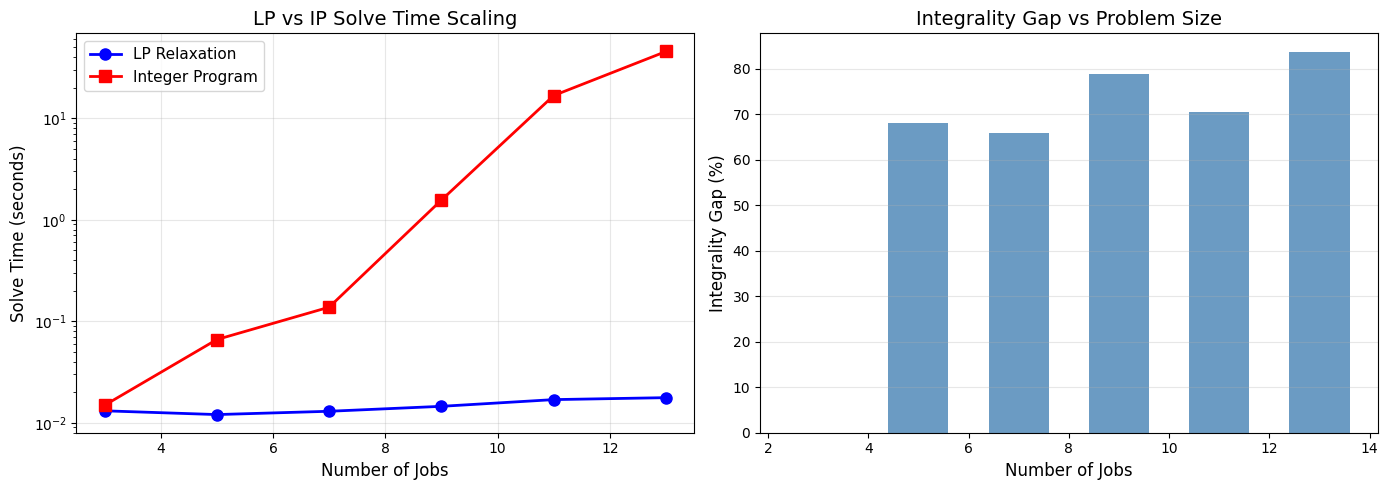

The LP relaxation scales gracefully (polynomial).
The IP solve time can grow exponentially — this is NP-hardness in action.


In [ ]:
# Plot the scaling behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solve time comparison
axes[0].plot(job_sizes, lp_times, 'b-o', label='LP Relaxation', linewidth=2, markersize=8)
axes[0].plot(job_sizes, ip_times, 'r-s', label='Integer Program', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Jobs', fontsize=12)
axes[0].set_ylabel('Solve Time (seconds)', fontsize=12)
axes[0].set_title('LP vs IP Solve Time Scaling', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Integrality gap
gaps = [abs(ip - lp) / abs(ip) * 100 if ip != 0 else 0
        for lp, ip in zip(lp_objs, ip_objs)]
axes[1].bar(job_sizes, gaps, color='steelblue', width=1.2, alpha=0.8)
axes[1].set_xlabel('Number of Jobs', fontsize=12)
axes[1].set_ylabel('Integrality Gap (%)', fontsize=12)
axes[1].set_title('Integrality Gap vs Problem Size', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('scaling_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("The LP relaxation scales gracefully (polynomial).")
print("The IP solve time can grow exponentially — this is NP-hardness in action.")


---

## Part 7: Exercises

### Exercise 1: Integrality Gap for Tmark

Solve both the LP relaxation and the IP for the Tmark facility location model. Compute and interpret the integrality gap.

**Hint:** Use `redeclare var y {WAREHOUSES} >= 0, <= 1;` for the LP relaxation.


In [ ]:
# =============================================
# EXERCISE 1: Your code here
# =============================================

# LP relaxation of Tmark
# tmark_lp = AMPL()
# ...

# IP of Tmark (already solved above — you can reuse the result)
# Compare and compute gap


### Exercise 2: Branch and Bound Trace

Using the `solve_bb_node` function from Part 3, trace the B&B tree for this IP:

$$\max \; 5x_1 + 4x_2$$
$$\text{s.t.} \; 3x_1 + 2x_2 \leq 12, \; x_1 + 3x_2 \leq 9, \; x_1, x_2 \geq 0 \text{ integer}$$

Write out the tree, including which nodes are pruned and why.


In [ ]:
# =============================================
# EXERCISE 2: Modify bb_example.mod or create a new model
# =============================================

# Hint: Write a new .mod file with the constraints above,
# then use solve_bb_node with different bound settings


### Exercise 3: Scaling the EMS Problem

Generate random EMS instances with 10, 20, 30, and 50 zones/sites. For each, solve the LP relaxation and IP, and plot the solve time and integrality gap.

**Hint:** Generate random coverage sets — for each zone, randomly select 2-4 sites that can cover it.


In [ ]:
# =============================================
# EXERCISE 3: Your code here
# =============================================

# def generate_ems_instance(n_zones, n_sites, coverage_density=3):
#     ...
#     return zones, sites, covers, costs


### Exercise 4: Gurobi Log Analysis

Solve the Wastewater network design problem with `outlev=1` and answer:

1. What is the root LP relaxation objective?
2. How many cutting planes were applied? What types?
3. How many B&B nodes were explored?
4. What is the final optimality gap?

Compare the root LP bound to the final IP objective — what is the integrality gap?


In [ ]:
# =============================================
# EXERCISE 4: Your code here
# =============================================

# Re-solve wastewater with verbose output and analyze the log
# waste_analysis = AMPL()
# ...


---

## Summary

| Topic | Key Takeaway |
|:------|:-------------|
| LP Relaxation | Drop integrality to get a bound; tighter is better |
| Integrality Gap | Measures LP relaxation quality; smaller = easier to solve |
| Branch and Bound | Systematic search with LP-based pruning |
| Cutting Planes | Tighten LP relaxation without losing integer solutions |
| Gurobi Solver Output | Gap, nodes, cuts, time — read the log! |
| Scaling | LP is polynomial; IP can be exponential — formulation matters |

### Assignment

Choose **one** of the following and submit a Colab notebook:

1. **Extend the scaling experiment:** Test the scheduling problem up to 15+ jobs. When does Gurobi hit the time limit? Plot solve time vs. problem size.
2. **Reformulation comparison:** Take the NASA model and create an alternative formulation (e.g., disaggregated budget constraints). Compare LP relaxation bounds and solve times.
3. **Your own IP:** Formulate and solve an integer programming problem from your research or coursework. Report the LP relaxation, integrality gap, and discuss what makes the problem easy or hard for the solver.

**Reading:** Rardin, Chapter 12 (Exact Methods for Integer Programming)
